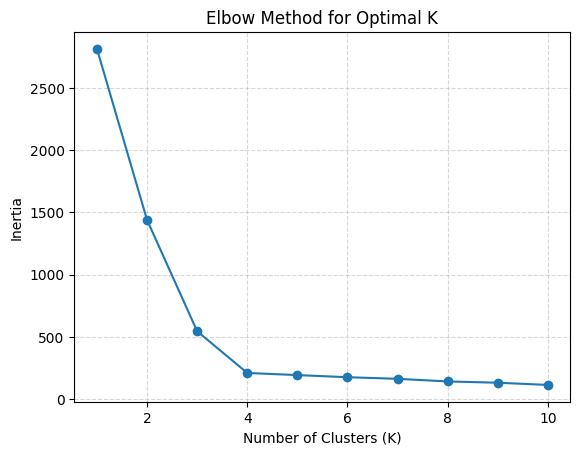

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1️⃣ 데이터 생성
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

# 2️⃣ K 값 범위 설정
k_range = range(1, 11)

inertias = []

# 3️⃣ 각 K에 대해 KMeans 학습
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)  # 응집도 # 저장 각 데이터 → 자기 중심점까지의 유클리드 거리 "제곱" 을 모두 더한 값

# 4️⃣ Elbow 그래프 시각화
plt.plot(k_range, inertias, marker='o')
# 눈금 추가
plt.grid(True,linestyle="--",alpha=0.5)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


Note: you may need to restart the kernel to use updated packages.
🔥 자동 선택된 최적 K: 4


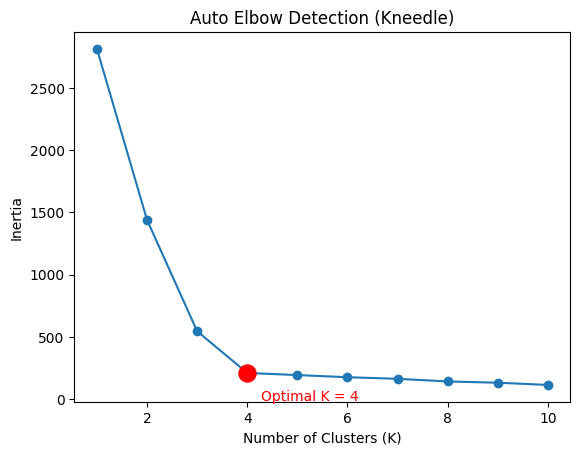

In [2]:
%pip install kneed
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from kneed import KneeLocator

# 1️⃣ 데이터 생성
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)

# 2️⃣ K 범위
k_range = range(1, 11)
inertias = []

# 3️⃣ KMeans 실행
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

#"Kneedle 알고리즘은 inertia 곡선의 꺾이는 지점을 자동으로 찾아 K를 결정한다"
# ✔ 핵심 원리
# 곡선에서 "급격히 꺾이는 지점" 찾기
# ✔ 수학적 느낌
# K 증가 → inertia 감소
# 감소율이 급격히 줄어드는 지점 탐색
#곡률 변화가 최대인 지점 = elbow

# 4️⃣ 🔥 Elbow 자동 탐지 (핵심)
knee = KneeLocator(
    k_range,
    inertias,
    curve="convex",
    direction="decreasing"
)

optimal_k = knee.knee
optimal_inertia = inertias[optimal_k - 1]

print("🔥 자동 선택된 최적 K:", optimal_k)

# 5️⃣ 시각화
plt.plot(k_range, inertias, marker='o')

# 🔴 최적 K 강조
plt.scatter(optimal_k, optimal_inertia, color='red', s=150, zorder=5)

plt.annotate(
    f"Optimal K = {optimal_k}",
    (optimal_k, optimal_inertia),
    textcoords="offset points",
    xytext=(10, -20),
    color='red'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Auto Elbow Detection (Kneedle)")
plt.show()

K=2 → 실루엣=0.455
K=3 → 실루엣=0.589
K=4 → 실루엣=0.682
K=5 → 실루엣=0.582
K=6 → 실루엣=0.485
K=7 → 실루엣=0.497
K=8 → 실루엣=0.404
K=9 → 실루엣=0.399
K=10 → 실루엣=0.338


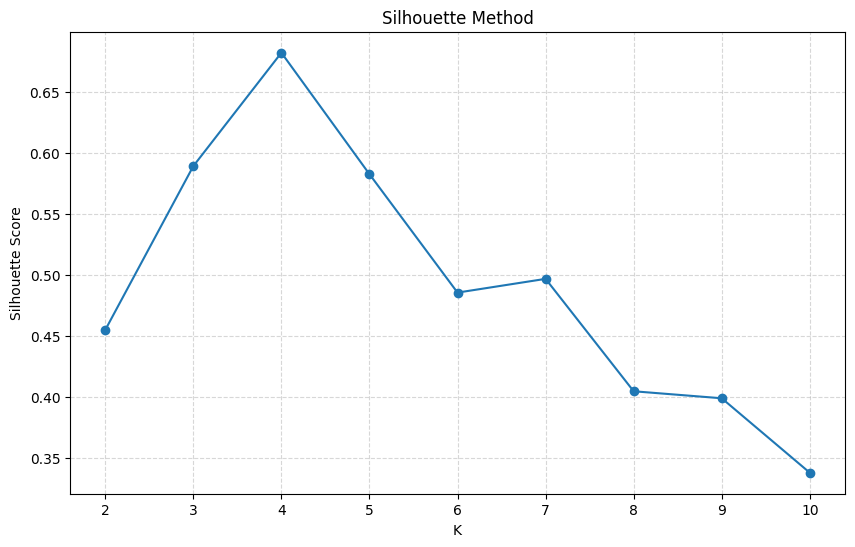

In [3]:
# 실루엣 계수
# 군집 품질 측정

# 실루엣 계수(Silhouette Score) 는 K-Means에서 가장 많이 쓰는 군집 품질 평가 지표

#"내가 속한 그룹 안에서는 얼마나 가깝고,
#다른 그룹과는 얼마나 멀리 떨어져 있는가?"

# +1 에 가까움 → 군집 잘 분리됨
# 0 근처 → 애매
# 음수 → 잘못 군집

import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# 1 데이터 생성
X, _ = make_blobs(
    n_samples=300,
    centers=4,
    cluster_std=0.60,
    random_state=0
)


# 2 K 범위
k_range = range(2, 11)

inertias = []
sil_scores = []


# 3 반복
for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=0
    )

    # 학습 + 군집 번호 예측
    labels = kmeans.fit_predict(X)
    # labels:
    # 각 데이터가 어떤 클러스터(0,1,2...)에 속하는지 저장

    # 응집도(SSE, Inertia) 저장
    inertias.append(kmeans.inertia_)
    # 각 데이터 → 자기 중심점까지의
    # 유클리드 거리² 을 전부 더한 값
    # 작을수록 군집 내부가 잘 뭉침
    
    # 실루엣 계수 계산
    score = silhouette_score(X,labels)
    # 같은 군집은 얼마나 가까운가(a)
    # 다른 군집은 얼마나 먼가(b)
    # 계산하여 -1 ~ 1 반환
    # 1에 가까울수록 좋은 군집

    # 결과 저장
    sil_scores.append(score)
    # K별 실루엣 점수를 저장
    # 나중에 그래프로 최적 K 찾기


# 결과 출력
for i in range(len(k_range)):
    print(f"K={k_range[i]} → 실루엣={sil_scores[i]:.3f}")


# ===================
# 실루엣 그래프
# ===================

plt.figure(figsize=(10,6))

plt.plot(
    k_range,
    sil_scores,
    marker="o"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.xticks(k_range)

plt.xlabel("K")
plt.ylabel("Silhouette Score")

plt.title(
    "Silhouette Method"
)

plt.show()

# Elbow
# +
# Silhouette
# 둘 다 확인

# Elbow → 거리 감소 확인
# Silhouette → 군집 품질 확인
# 둘이 같은 K를 가리키면 꽤 신뢰도가 높아짐